# UC model variants — visual comparison

Inspect what the three model tweaks actually do: per-sensor time series with
acceptance bands, confusion matrices, metric tables, histograms, and an
adjustable detection threshold.

| variant | transform | daily harmonics | signed bands |
|---|---|---|---|
| `baseline` | raw | 2 | no |
| `log1p` | `log1p(Diff/s)` | 2 | no |
| `harmonics4` | raw | adaptive ≤4 | no |
| `signed` | raw | 2 | yes |
| `log1p_signed` | `log1p(Diff/s)` | 2 | yes |
| `all3` | `log1p(Diff/s)` | adaptive ≤4 | yes |

**The threshold is a display-time parameter.** Moving it re-derives the flags
*and* the drawn bands from values stored per reading — no model is re-run.

**Watch out when comparing at a fixed `z`.** Signed bands change what the
threshold means: for Gaussian residuals a folded band at `z=3.5` sits at
≈2.91σ while a signed one sits at 3.5σ, roughly 15× stricter. Use the
precision–recall curve at the bottom to compare at matched alert volume.

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, '.')
warnings.filterwarnings('ignore')
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 60)
plt.rcParams['figure.facecolor'] = 'white'

import uc_variants as uv
import variant_viz as vz

print('variants:', list(uv.VARIANTS))

variants: ['baseline', 'log1p', 'harmonics4', 'signed', 'log1p_signed', 'all3']


## Configuration

Everything you would normally want to change lives here.
`FIXTURES_DIR` currently points at the three real sensors bundled in the
`uc-cem` repo; swap it for `../../../data/sensor_data` once the full dataset
is downloaded.

In [2]:
# --- edit these -------------------------------------------------------
FIXTURES_DIR = '/home/user/uc-cem/testing_scripts/fixtures/real_segments'
VARIANTS     = ['baseline', 'log1p', 'harmonics4', 'signed', 'log1p_signed', 'all3']
Z_THRESHOLD  = 3.5      # detection threshold used by the plots below
SENSOR       = None     # None -> first sensor found
# ----------------------------------------------------------------------

files = sorted(str(p) for p in Path(FIXTURES_DIR).glob('*.csv'))
print(f'{len(files)} sensors:', [Path(f).stem for f in files])

3 sensors: ['100005', '100015', '100020']


## Run the variants

Each sensor is run once per variant and the per-reading frame is kept in
memory. Windows and injected anomalies are seeded on `int(filename)`, so every
variant sees **identical** windows and identical injected spikes — the
comparison is paired per sensor.

In [3]:
all_frames, summary_rows = {}, []

for f in files:
    sensor = Path(f).stem
    frames = {}
    for v in VARIANTS:
        res, df = uv.run_variant_with_frame(f, v)
        if res['status'] != 'success':
            print(f'  {sensor}/{v}: FAILED - {res["error"]}')
            continue
        frames[v] = dict(df=df, signed=res['opt_signed_bands'],
                         transform=res['transform'],
                         scale=res.get('transform_scale_used', 1.0))
        summary_rows.append({k: val for k, val in res.items()
                             if not isinstance(val, (list, pd.DataFrame))})
    if frames:
        all_frames[sensor] = frames
    print(f'{sensor}: {len(frames)} variants ok')

summary = pd.DataFrame(summary_rows)
if SENSOR is None:
    SENSOR = list(all_frames)[0]
print('\ninspecting sensor:', SENSOR)

100005: 6 variants ok


100015: 6 variants ok


100020: 6 variants ok

inspecting sensor: 100005


## 1. Single-sensor time series

The prediction week for one sensor under each variant. Shaded region is the
acceptance band; anything outside it is flagged. Markers show true positives,
false positives and misses.

Under `log1p` the band is visibly **asymmetric in raw units** — wider above the
prediction than below. That is the transform working: it is symmetric in the
space the model actually scores in.

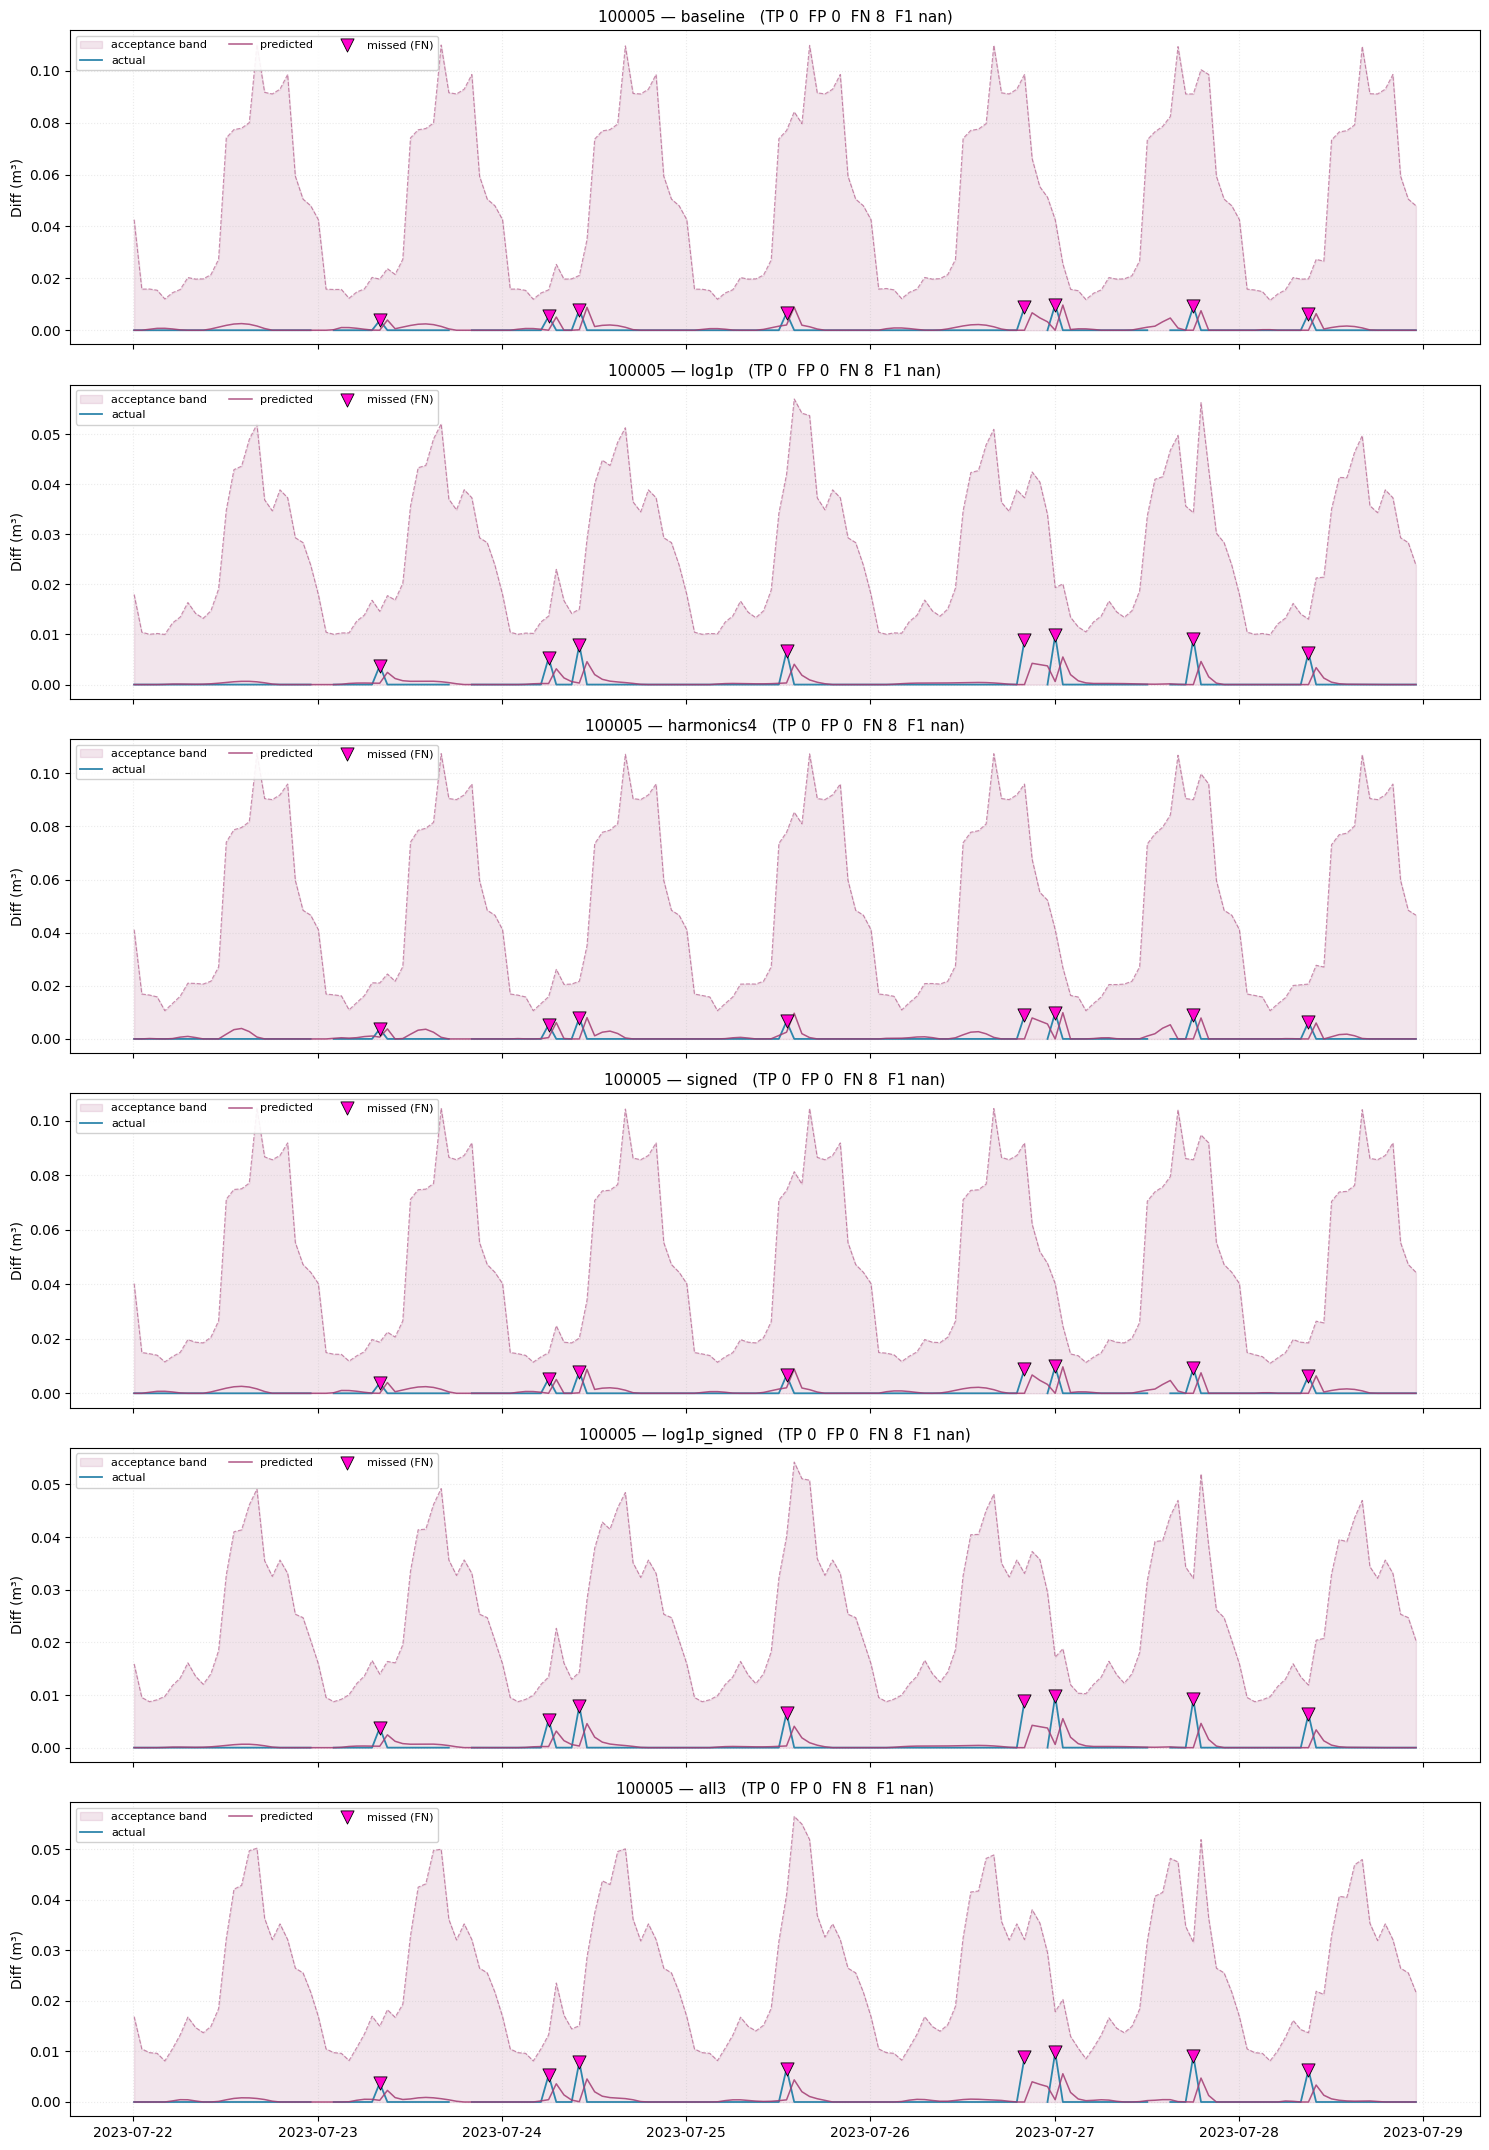

In [4]:
fig = vz.compare_sensor_variants(all_frames[SENSOR], SENSOR, z_threshold=Z_THRESHOLD)
plt.show()

### Zoom on a shorter window

Set `START` / `END` to inspect individual detections.

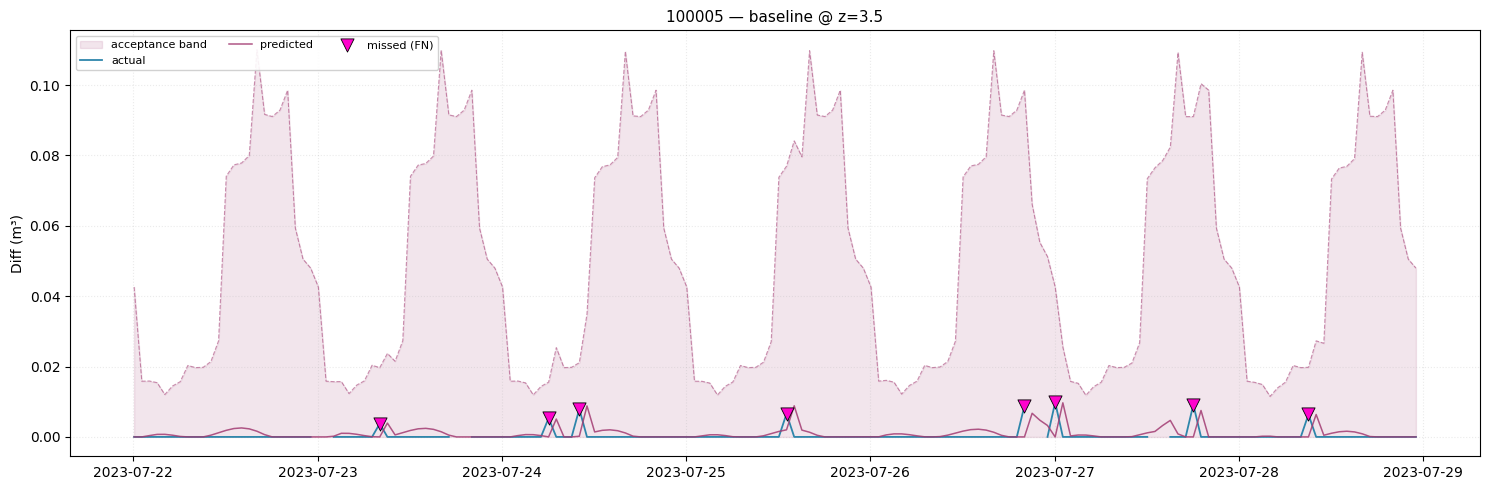

In [5]:
START, END = None, None   # e.g. '2025-06-10', '2025-06-13'

meta = all_frames[SENSOR]['baseline']
d = vz.recompute_at_threshold(meta['df'], Z_THRESHOLD, meta['signed'],
                              meta['transform'], meta['scale'])
vz.plot_sensor_timeseries(d, title=f'{SENSOR} — baseline @ z={Z_THRESHOLD}',
                          start=START, end=END, figsize=(15, 5))
plt.show()

## 2. Adjust the detection threshold

Both the flags **and** the bands are recomputed. If only the flags moved, the
plot would misrepresent what the detector is doing.

A slider appears if `ipywidgets` is installed (`pip install ipywidgets`);
otherwise change `Z_THRESHOLD` above and re-run.

,variant,tp,fp,fn,tn,n_sensors,precision,recall,f1,fp_per_sensor_week
0,log1p_signed,6,1,11,484,3,0.857143,0.352941,0.500000,0.333333
1,baseline,7,5,10,480,3,0.583333,0.411765,0.482759,1.666667
2,signed,7,5,10,480,3,0.583333,0.411765,0.482759,1.666667
3,harmonics4,7,5,10,480,3,0.583333,0.411765,0.482759,1.666667
4,log1p,6,2,11,483,3,0.750000,0.352941,0.480000,0.666667
5,all3,5,1,12,484,3,0.833333,0.294118,0.434783,0.333333


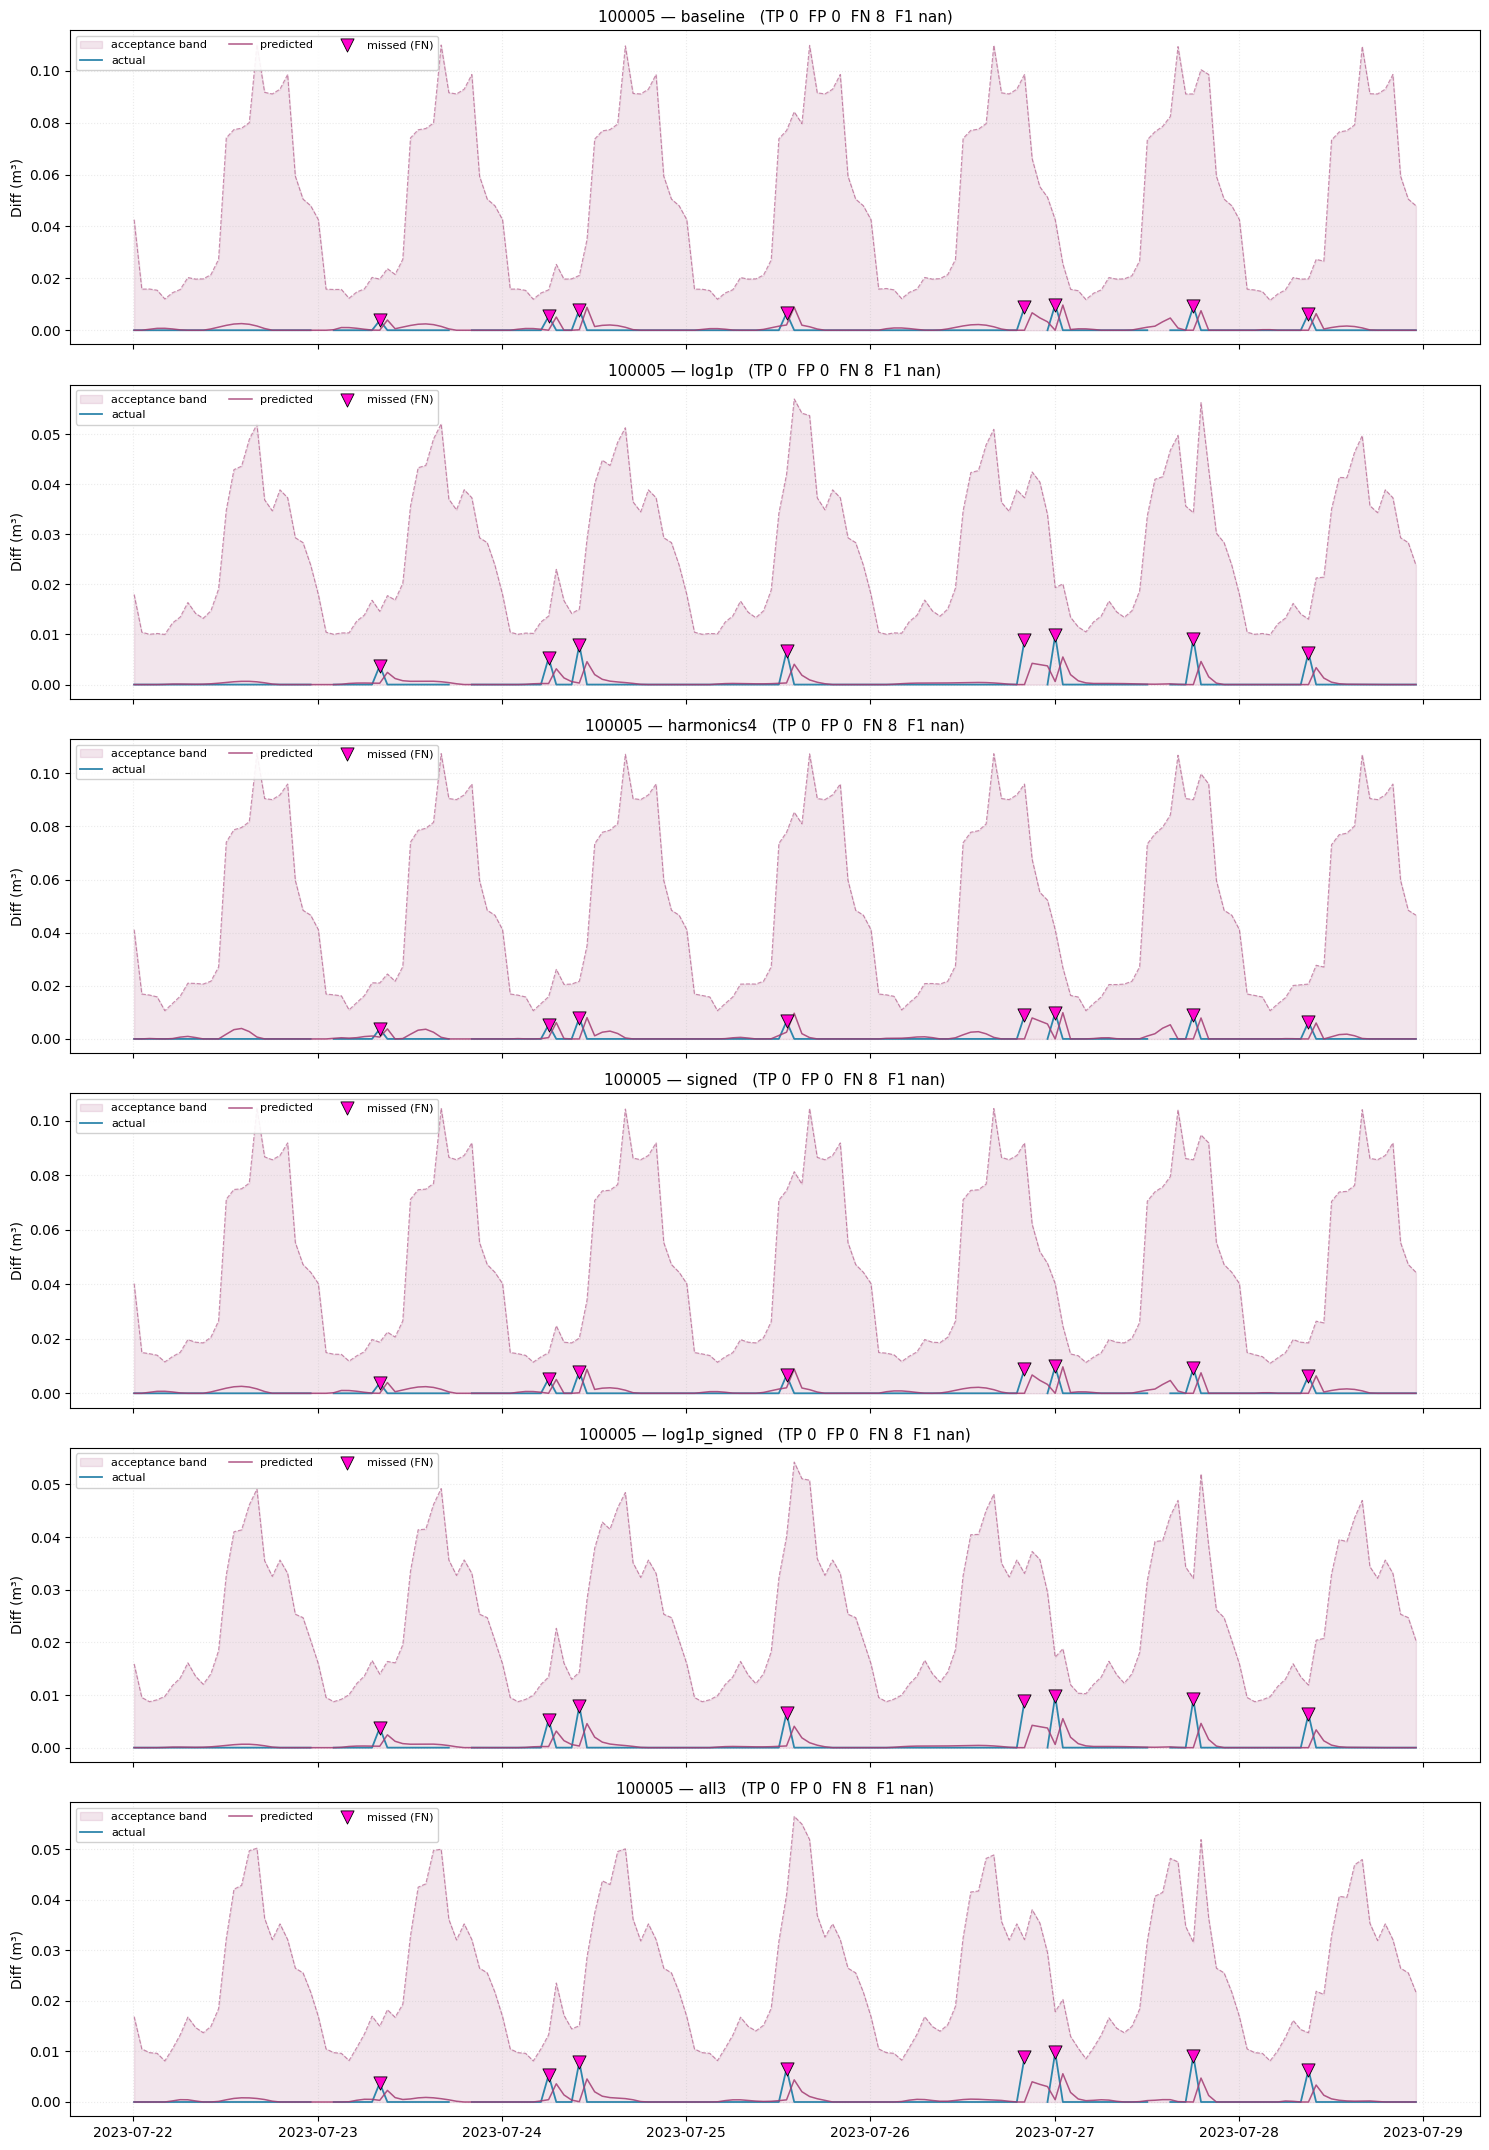

interactive(children=(FloatSlider(value=3.5, continuous_update=False, description='z:', max=6.0, min=1.5), Out…

In [6]:
def render(z):
    z = float(z)
    display(vz.micro_table_multi(all_frames, z_threshold=z))
    vz.compare_sensor_variants(all_frames[SENSOR], SENSOR, z_threshold=z)
    plt.show()

from IPython.display import display

# Always render once so the cell has output even when saved/exported.
render(Z_THRESHOLD)

# ...then add a live slider on top, if ipywidgets is available.
try:
    import ipywidgets as widgets
    slider = widgets.FloatSlider(value=Z_THRESHOLD, min=1.5, max=6.0, step=0.1,
                                 description='z:', continuous_update=False)
    display(widgets.interactive(render, z=slider))
except ImportError:
    print('ipywidgets not installed (pip install ipywidgets) — '
          'edit Z_THRESHOLD above and re-run for a different threshold.')

## 3. Confusion matrices

Pooled over all sensors, at the current threshold. Rows are normalised because
the class imbalance is extreme — a handful of injected anomalies against a full
week of normal readings — so raw counts would render the anomaly row invisible.

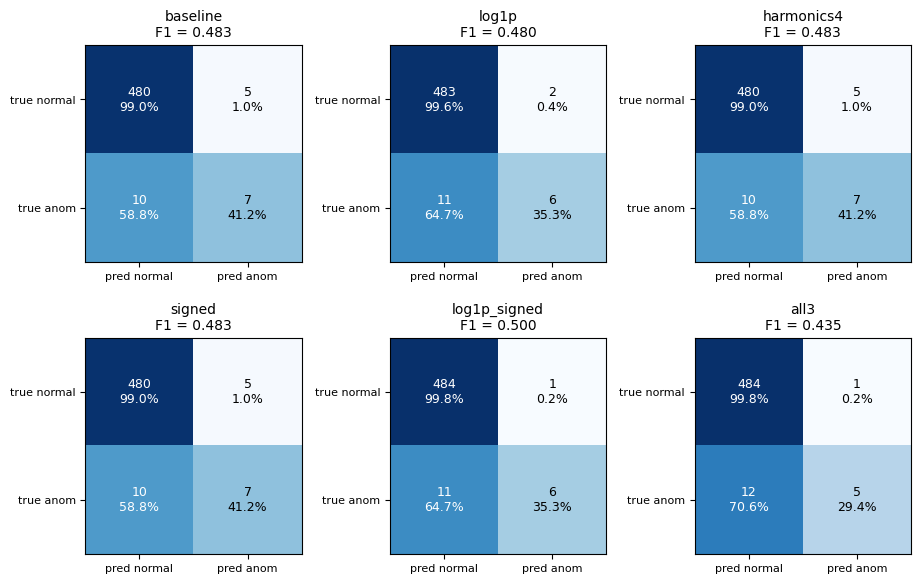

In [7]:
counts = vz.pooled_counts(all_frames, z_threshold=Z_THRESHOLD)
fig = vz.plot_confusion_matrices(counts)
plt.show()

## 4. Metrics table

Micro-averaged: `tp`/`fp`/`fn` are summed across sensors and precision/recall/F1
computed once. Averaging per-sensor F1 would hide false-positive floods.

The prediction segment is exactly one week, so `fp_per_sensor_week` is literally
alerts per sensor per week — the number Softlink feels operationally.

In [8]:
micro = vz.micro_table_multi(all_frames, z_threshold=Z_THRESHOLD)
display(micro.style.format({'precision': '{:.3f}', 'recall': '{:.3f}',
                            'f1': '{:.3f}', 'fp_per_sensor_week': '{:.2f}'}))

,variant,tp,fp,fn,tn,n_sensors,precision,recall,f1,fp_per_sensor_week
0,log1p_signed,6,1,11,484,3,0.857,0.353,0.500,0.33
1,baseline,7,5,10,480,3,0.583,0.412,0.483,1.67
2,signed,7,5,10,480,3,0.583,0.412,0.483,1.67
3,harmonics4,7,5,10,480,3,0.583,0.412,0.483,1.67
4,log1p,6,2,11,483,3,0.750,0.353,0.480,0.67
5,all3,5,1,12,484,3,0.833,0.294,0.435,0.33


### Per-sensor accuracy (threshold-independent)

MASE and MAE do not depend on the detection threshold — they measure the
forecast, not the alarm. Useful for separating *better model* from
*better-tuned threshold*.

In [9]:
acc = (summary[summary.status == 'success']
       .pivot_table(index='filename', columns='variant',
                    values='mase_seasonal', aggfunc='first'))
print('mase_seasonal (lower is better)')
display(acc.style.format('{:.3f}').background_gradient(cmap='RdYlGn_r', axis=1))

mae = (summary[summary.status == 'success']
       .pivot_table(index='filename', columns='variant',
                    values='metric_mae', aggfunc='first'))
print('\nmetric_mae (raw units, lower is better)')
display(mae.style.format('{:.5f}').background_gradient(cmap='RdYlGn_r', axis=1))

mase_seasonal (lower is better)


variant,all3,baseline,harmonics4,log1p,log1p_signed,signed
filename,,,,,,
100005,0.080,0.146,0.139,0.074,0.074,0.146
100015,0.686,0.884,0.894,0.663,0.663,0.884
100020,0.927,0.969,0.986,0.899,0.903,0.969



metric_mae (raw units, lower is better)


variant,all3,baseline,harmonics4,log1p,log1p_signed,signed
filename,,,,,,
100005,0.00081,0.00119,0.00114,0.00078,0.00078,0.00119
100015,0.03922,0.04963,0.05011,0.03802,0.03802,0.04963
100020,0.00860,0.00891,0.00899,0.00852,0.00853,0.00891


## 5. Histograms

### z-score separation

How well the score separates anomalies from normal readings. This is what a
better detector actually buys — F1 at one threshold is a single vertical slice
of this picture. Counts are log-scaled.

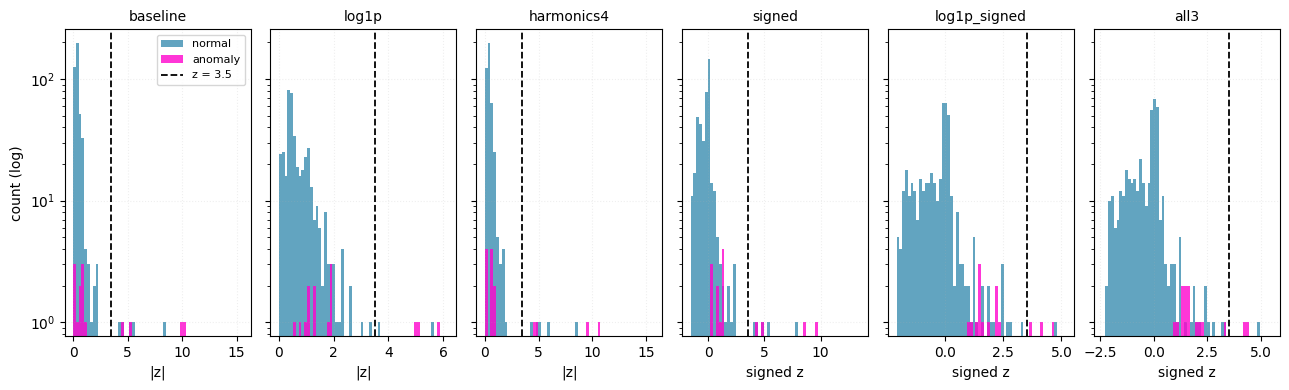

In [10]:
pooled = vz.pool_frames(all_frames)
fig = vz.plot_zscore_histogram(pooled, z_threshold=Z_THRESHOLD)
plt.show()

### Accuracy metric distributions across sensors

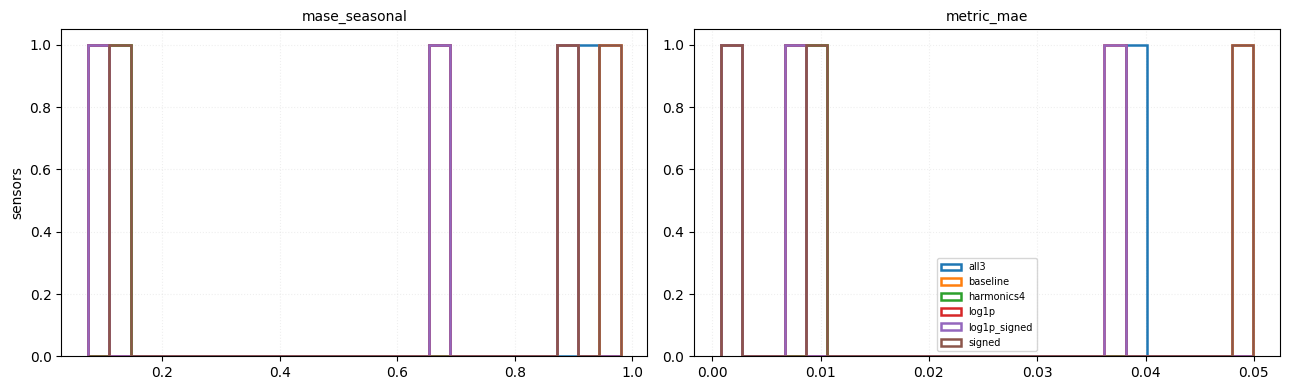

In [11]:
fig = vz.plot_metric_histograms(summary, metrics=('mase_seasonal', 'metric_mae'))
plt.show()

### False-positive concentration

A steep curve means most alerts come from a few sensors — the FP-flood failure
mode that micro-F1 alone will not reveal.

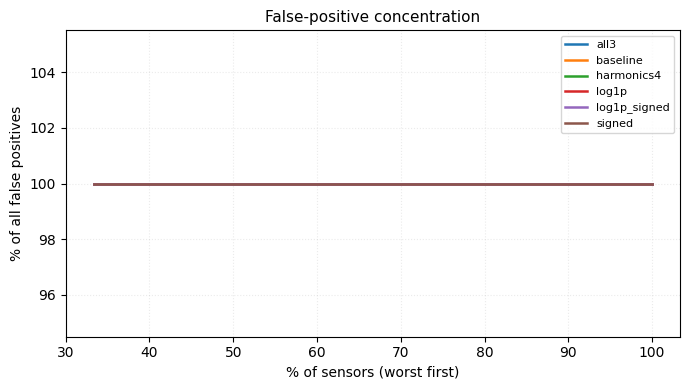

In [12]:
fig = vz.plot_fp_distribution(summary)
plt.show()

## 6. Threshold sweep

**This is the comparison that matters.** Because signed bands change the meaning
of `z`, comparing variants at one fixed threshold confuses *a moved operating
point* with *a genuinely better detector*. A variant that is really better
dominates on the precision–recall curve; one that is merely retuned just slides
along the same curve.

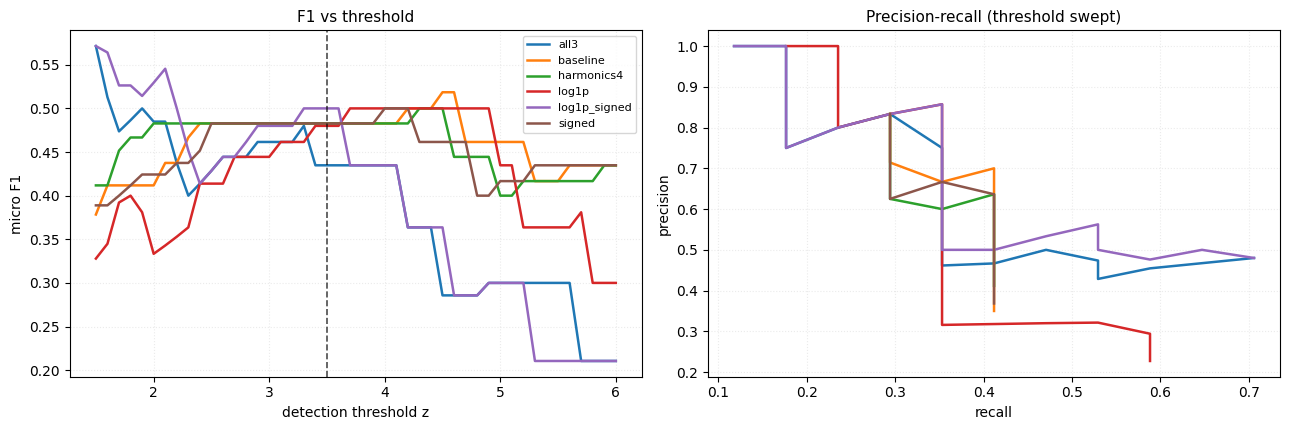

peak F1 per variant (threshold swept):


,variant,z,tp,fp,fn,precision,recall,f1
0,all3,1.500000,12,13,5,0.480,0.706,0.571
1,log1p_signed,1.500000,12,13,5,0.480,0.706,0.571
2,baseline,4.500000,7,3,10,0.700,0.412,0.519
3,harmonics4,4.300000,7,4,10,0.636,0.412,0.500
4,log1p,3.700000,6,1,11,0.857,0.353,0.500
5,signed,4.000000,7,4,10,0.636,0.412,0.500


In [13]:
sweep = vz.sweep_frames(pooled)
fig = vz.plot_sweep(sweep, z_threshold=Z_THRESHOLD)
plt.show()

best = sweep.loc[sweep.groupby('variant')['f1'].idxmax()]
print('peak F1 per variant (threshold swept):')
display(best.sort_values('f1', ascending=False)
        .reset_index(drop=True)
        .style.format({'precision': '{:.3f}', 'recall': '{:.3f}', 'f1': '{:.3f}'}))

---

**Caveat on these numbers.** With only the three bundled fixture sensors this is
a smoke test of the tooling, not evidence about the model — a handful of
injected anomalies cannot separate the variants. Point `FIXTURES_DIR` at the
full dataset for conclusions, and use `run_variants.py` +
`analyze_variants.py` (which adds paired bootstrap confidence intervals and the
production-gate cohort slider) for the fleet-scale run.